In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer


In [ ]:
train_data = pd.read_csv('train_FD001.txt', sep=' ', header=None)
test_data = pd.read_csv('test_FD001.txt', sep=' ', header=None)


In [ ]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nMissing values in train:")
print(train_data.isnull().sum())

print("\nMissing values in test:")
print(test_data.isnull().sum())


Train shape: (20631, 28)
Test shape: (13096, 28)

Missing values in train:
0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
24        0
25        0
26    20631
27    20631
dtype: int64

Missing values in test:
0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
24        0
25        0
26    13096
27    13096
dtype: int64


In [ ]:
# Columns with missing values (0-based indexing)
cols_to_impute = [26, 27]

# Copy data
train_data_imputed = train_data.copy()
test_data_imputed = test_data.copy()

# KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# Impute only selected columns, one at a time
for col in cols_to_impute:
    train_data_imputed[col] = imputer.fit_transform(train_data[[col]])
    test_data_imputed[col] = imputer.transform(test_data[[col]])


In [ ]:
print(f"Shape of train_data_imputed: {train_data_imputed.shape}")
print(f"Shape of test_data_imputed: {test_data_imputed.shape}")


Shape of train_data_imputed: (20631, 28)
Shape of test_data_imputed: (13096, 28)


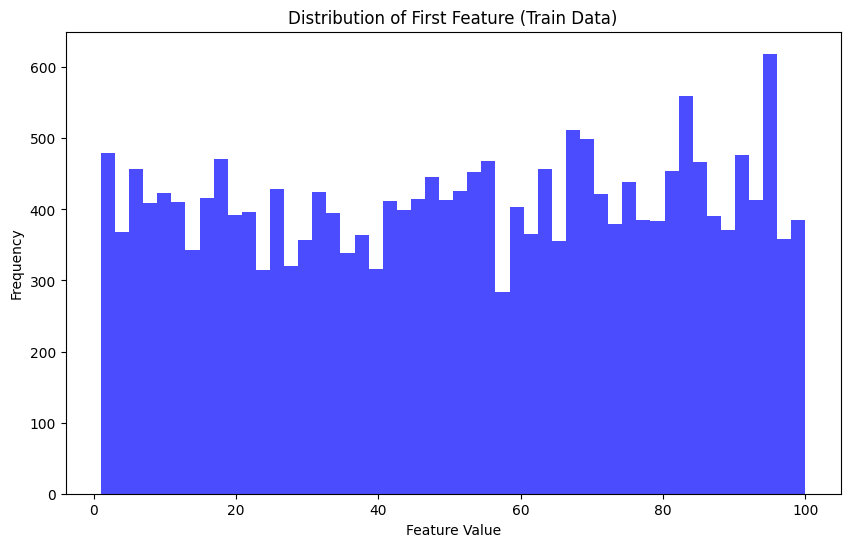

In [ ]:
import matplotlib.pyplot as plt

# Visualize the distribution of data in the first column of the training set after imputation
plt.figure(figsize=(10, 6))
plt.hist(train_data_imputed.iloc[:, 0], bins=50, color='blue', alpha=0.7)
plt.title("Distribution of First Feature (Train Data)")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Assuming the RUL file is named 'RUL_FD001.txt' and corresponds to your data
rul_data = pd.read_csv('RUL_FD001.txt', header=None)
rul_data.columns = ['RUL']  # Set the column name for RUL


In [ ]:
# Ensure the RUL data aligns with the train_data
train_data_imputed['RUL'] = rul_data  # Assuming both train_data_imputed and rul_data are aligned by index


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming your data (with RUL column) is in 'train_data_imputed' and 'RUL' is the target
X = train_data_imputed.drop('RUL', axis=1)  # Features (all columns except 'RUL')
y = train_data_imputed['RUL']  # Target (the RUL column)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optionally, you can also split the training set into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Verify the shapes of the splits
print(f"Training set: {X_train_split.shape}, Validation set: {X_val_split.shape}, Test set: {X_test.shape}")


Training set: (13203, 28), Validation set: (3301, 28), Test set: (4127, 28)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data, then transform the validation and test data
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test)

# Verify the shapes of the scaled data
print(f"Scaled Training set: {X_train_scaled.shape}")
print(f"Scaled Validation set: {X_val_scaled.shape}")
print(f"Scaled Test set: {X_test_scaled.shape}")


Scaled Training set: (13203, 28)
Scaled Validation set: (3301, 28)
Scaled Test set: (4127, 28)


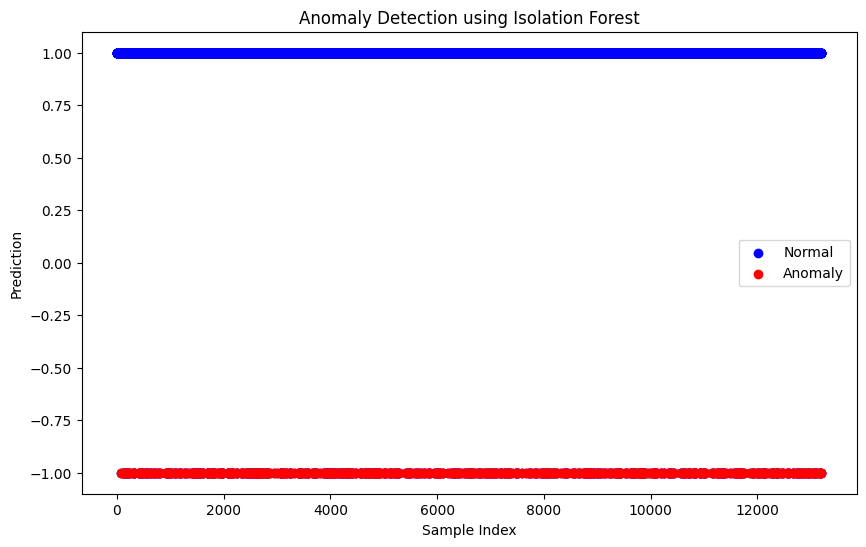

In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model
iso_forest.fit(X_train_scaled)

# Predict anomalies (1 = normal, -1 = anomaly)
y_train_pred = iso_forest.predict(X_train_scaled)
y_val_pred = iso_forest.predict(X_val_scaled)
y_test_pred = iso_forest.predict(X_test_scaled)

# Visualize the anomalies
import numpy as np
import matplotlib.pyplot as plt

# Anomalies are marked as -1
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_train_pred)), y_train_pred, color='blue', label='Normal')
plt.scatter(np.arange(len(y_train_pred))[y_train_pred == -1], y_train_pred[y_train_pred == -1], color='red', label='Anomaly')
plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.legend()
plt.show()


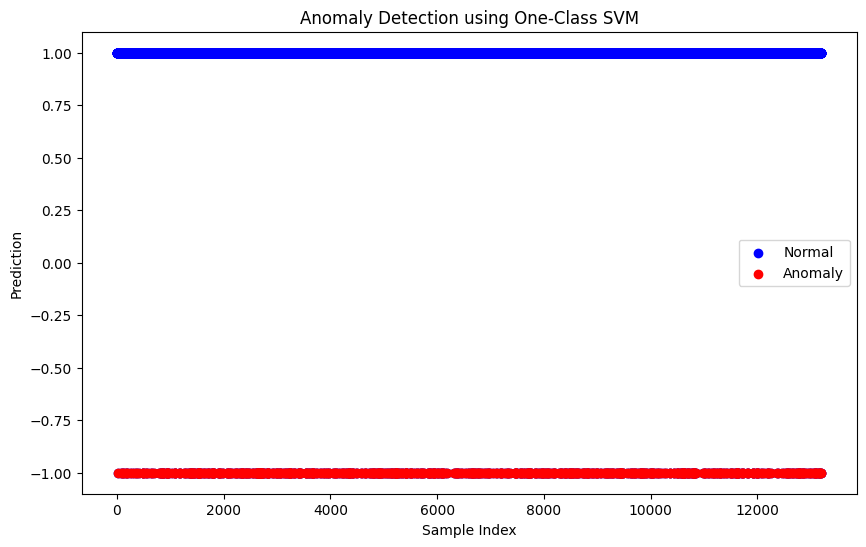

In [ ]:

from sklearn.svm import OneClassSVM

# Initialize One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)

# Fit the model
ocsvm.fit(X_train_scaled)

# Predict anomalies (1 = normal, -1 = anomaly)
y_train_pred = ocsvm.predict(X_train_scaled)
y_val_pred = ocsvm.predict(X_val_scaled)
y_test_pred = ocsvm.predict(X_test_scaled)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_train_pred)), y_train_pred, color='blue', label='Normal')
plt.scatter(np.arange(len(y_train_pred))[y_train_pred == -1], y_train_pred[y_train_pred == -1], color='red', label='Anomaly')
plt.title("Anomaly Detection using One-Class SVM")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.legend()
plt.show()


In [ ]:
print(test_data)

        0    1       2       3      4       5       6        7        8   \
0        1    1  0.0023  0.0003  100.0  518.67  643.02  1585.29  1398.21   
1        1    2 -0.0027 -0.0003  100.0  518.67  641.71  1588.45  1395.42   
2        1    3  0.0003  0.0001  100.0  518.67  642.46  1586.94  1401.34   
3        1    4  0.0042  0.0000  100.0  518.67  642.44  1584.12  1406.42   
4        1    5  0.0014  0.0000  100.0  518.67  642.51  1587.19  1401.92   
...    ...  ...     ...     ...    ...     ...     ...      ...      ...   
13091  100  194  0.0049  0.0000  100.0  518.67  643.24  1599.45  1415.79   
13092  100  195 -0.0011 -0.0001  100.0  518.67  643.22  1595.69  1422.05   
13093  100  196 -0.0006 -0.0003  100.0  518.67  643.44  1593.15  1406.82   
13094  100  197 -0.0038  0.0001  100.0  518.67  643.26  1594.99  1419.36   
13095  100  198  0.0013  0.0003  100.0  518.67  642.95  1601.62  1424.99   

          9   ...       18      19    20   21    22     23     24       25  \
0      14

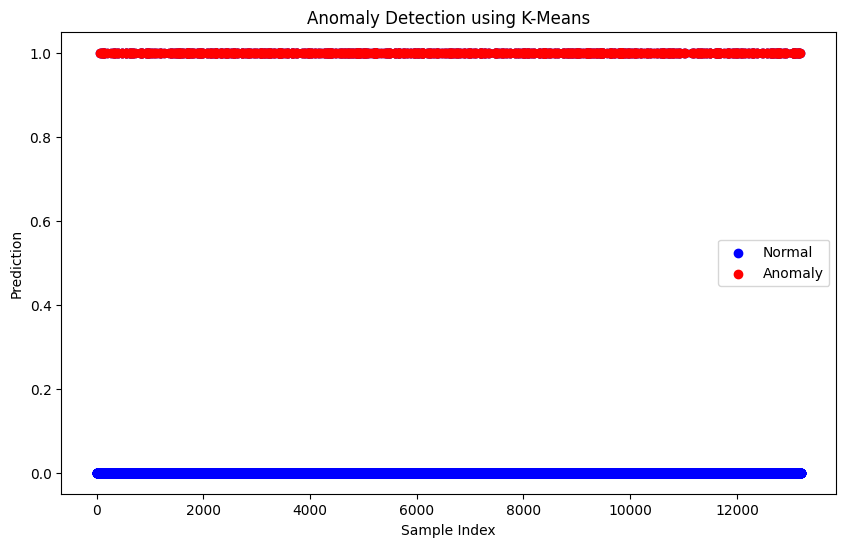

In [ ]:
from sklearn.cluster import KMeans

# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model
kmeans.fit(X_train_scaled)

# Get the distance from the cluster centers
distances = kmeans.transform(X_train_scaled).min(axis=1)

# Define a threshold for anomalies
threshold = np.percentile(distances, 95)

# Identify anomalies
y_train_pred = (distances > threshold).astype(int)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_train_pred)), y_train_pred, color='blue', label='Normal')
plt.scatter(np.arange(len(y_train_pred))[y_train_pred == 1], y_train_pred[y_train_pred == 1], color='red', label='Anomaly')
plt.title("Anomaly Detection using K-Means")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.legend()
plt.show()


Accuracy: 0.9497
Precision: 0.9998
Recall: 0.9499
F1 Score: 0.9742
Confusion Matrix:
[[    0     3]
 [  661 12539]]


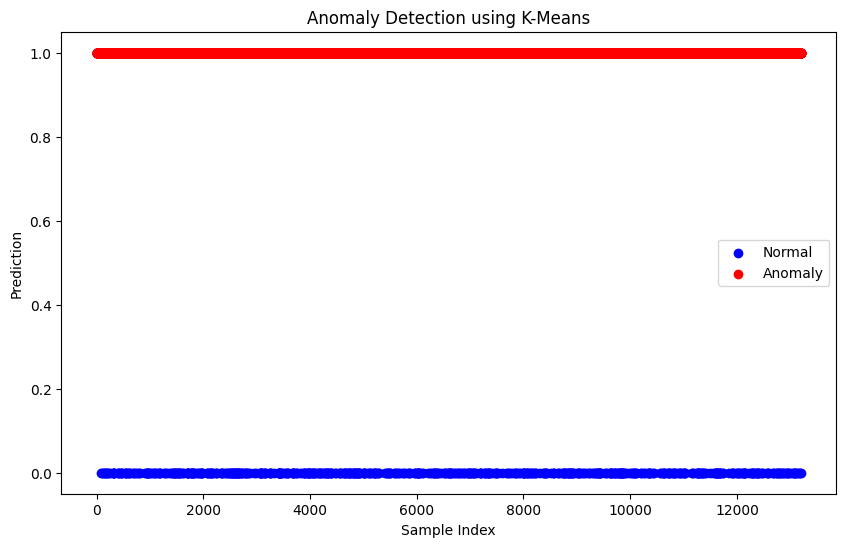

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming y_true contains the true labels for your dataset (you need to replace this with your actual labels)
# Example: For demonstration, I'm assuming 13203 samples, and setting all to 1 (normal) for now
# In your case, this should match the length of y_train_pred
y_true = np.ones(len(y_train_pred))  # Example: all samples are normal (replace with actual ground truth)
# Example: If you have anomaly indices, you can set those indices to -1
# For demonstration, let's assume anomalies are at indices 100, 200, 300
anomaly_indices = [100, 200, 300]
y_true[anomaly_indices] = -1  # Set anomalies

# Ensure that y_true matches the number of samples in y_train_pred
assert len(y_true) == len(y_train_pred), "The number of samples in y_true and y_train_pred must match."

# Convert the predictions from [1, -1] to [0, 1] for compatibility with metrics
y_train_pred_binary = (y_train_pred == 1).astype(int)  # Normal -> 0, Anomaly -> 1
y_true_binary = (y_true == 1).astype(int)  # Normal -> 0, Anomaly -> 1

# Calculate the metrics
accuracy = accuracy_score(y_true_binary, y_train_pred_binary)
precision = precision_score(y_true_binary, y_train_pred_binary)
recall = recall_score(y_true_binary, y_train_pred_binary)
f1 = f1_score(y_true_binary, y_train_pred_binary)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true_binary, y_train_pred_binary)
print("Confusion Matrix:")
print(cm)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_train_pred)), y_train_pred_binary, color='blue', label='Normal')
plt.scatter(np.arange(len(y_train_pred))[y_train_pred_binary == 1], y_train_pred_binary[y_train_pred_binary == 1], color='red', label='Anomaly')
plt.title("Anomaly Detection using K-Means")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.legend()
plt.show()


In [ ]:
import pickle

# Save your model or data
with open('model.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

# If you have a scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [ ]:
import pickle

# Load your model or data
with open('model.pkl', 'rb') as f:
    iso_forest = pickle.load(f)

# If you have a scaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)


In [ ]:
import joblib
import numpy as np
from sklearn.ensemble import IsolationForest

# Example: Train a model (Isolation Forest in this case)
# Replace this with your actual model
X_train = np.random.rand(100, 2)  # Replace with your training data
iso_forest = IsolationForest(random_state=42)

# Train the model
iso_forest.fit(X_train)

# Save the model using joblib
model_filename = 'iso_forest_model.pkl'
joblib.dump(iso_forest, model_filename)
print(f"Model saved as {model_filename}")

# Save the scaler (if using any) for later use
# For example, saving the scaler if you use one for feature scaling:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Save the scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as {scaler_filename}")

# --- Now, let's simulate restarting the kernel ---
# Code to load the model and scaler after a kernel restart

# Load the model
iso_forest_loaded = joblib.load(model_filename)
print("Model loaded successfully.")

# Load the scaler
scaler_loaded = joblib.load(scaler_filename)
print("Scaler loaded successfully.")

# --- Check if the model works ---
# Test with a sample data point
sample_data = np.random.rand(1, 2)  # Replace with your actual test data

# Preprocess the test data using the loaded scaler
sample_data_scaled = scaler_loaded.transform(sample_data)

# Use the loaded model to make a prediction
prediction = iso_forest_loaded.predict(sample_data_scaled)

print(f"Prediction for the sample data: {prediction}")


Model saved as iso_forest_model.pkl
Scaler saved as scaler.pkl
Model loaded successfully.
Scaler loaded successfully.
Prediction for the sample data: [-1]


Accuracy: 0.5067
Precision: 0.9999
Recall: 0.5067
F1 Score: 0.6725
Confusion Matrix:
[[   2    1]
 [6512 6688]]


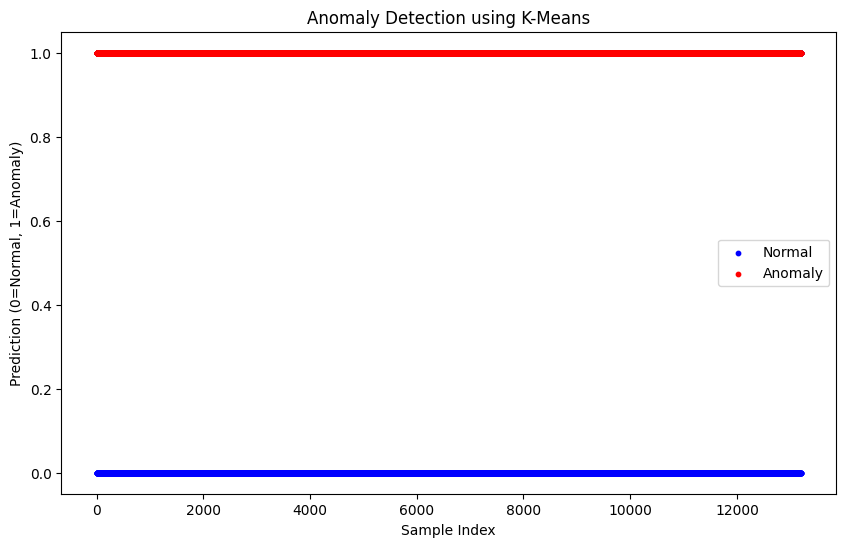

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans

# Assuming y_true and y_train_pred are already available
# Example data, replace this with your actual y_train_pred and y_true
y_train_pred = np.random.choice([1, -1], size=13203)  # Example prediction
y_true = np.ones(len(y_train_pred))  # All normal initially
anomaly_indices = [100, 200, 300]
y_true[anomaly_indices] = -1  # Set anomalies at these indices

# Ensure that y_true matches the number of samples in y_train_pred
assert len(y_true) == len(y_train_pred), "The number of samples in y_true and y_train_pred must match."

# Convert the predictions from [1, -1] to [0, 1] for compatibility with metrics
y_train_pred_binary = (y_train_pred == 1).astype(int)  # Normal -> 0, Anomaly -> 1
y_true_binary = (y_true == 1).astype(int)  # Normal -> 0, Anomaly -> 1

# Calculate the metrics
accuracy = accuracy_score(y_true_binary, y_train_pred_binary)
precision = precision_score(y_true_binary, y_train_pred_binary)
recall = recall_score(y_true_binary, y_train_pred_binary)
f1 = f1_score(y_true_binary, y_train_pred_binary)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true_binary, y_train_pred_binary)
print("Confusion Matrix:")
print(cm)

# Visualize the anomalies with a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y_train_pred)), y_train_pred_binary, color='blue', label='Normal', s=10)
plt.scatter(np.arange(len(y_train_pred))[y_train_pred_binary == 1], y_train_pred_binary[y_train_pred_binary == 1], color='red', label='Anomaly', s=10)
plt.title("Anomaly Detection using K-Means")
plt.xlabel("Sample Index")
plt.ylabel("Prediction (0=Normal, 1=Anomaly)")
plt.legend()
plt.show()
